In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("cleaned_churn.csv")

X = df[["total_day_minutes"]]   # input (the double brackets are needed)
y = df["total_day_charge"]      # what we predict

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 533
Test rows: 134


In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Slope (coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (coefficient): 0.17000134315009316
Intercept: 0.00029210176267469024


In [7]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-squared:", r2_score(y_test, y_pred))
print("Mean squared error:", mean_squared_error(y_test, y_pred))

Slope: 0.17000134315009316
Intercept: 0.00029210176267469024
R-squared: 0.9999999063773476
Mean squared error: 8.073911063473385e-06


In [8]:
y_pred = model.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))
print("Mean squared error:", mean_squared_error(y_test, y_pred))

R-squared: 0.9999999063773476
Mean squared error: 8.073911063473385e-06


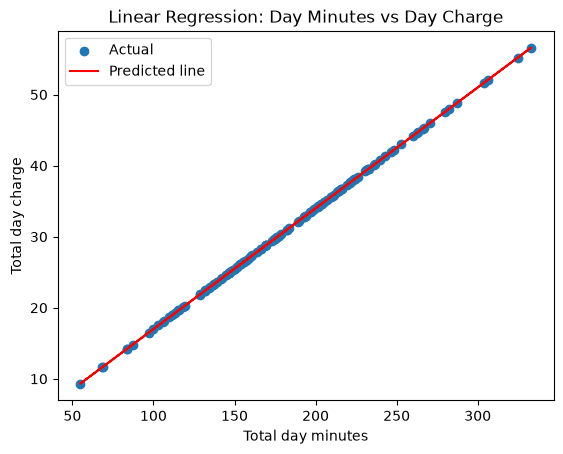

In [11]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted line")
plt.xlabel("Total day minutes")
plt.ylabel("Total day charge")
plt.title("Linear Regression: Day Minutes vs Day Charge")
plt.legend()
plt.savefig("regression_day.png", dpi=150, bbox_inches="tight")
plt.show()

A linear regression predicting total day charge from total day minutes was trained on 80% of the data and tested on the remaining 20%. The slope of about 0.17 means each extra minute adds roughly 0.17 to the charge. The R-squared is almost 1.0 and the error is near zero, because charge is computed directly from minutes. This is a useful demonstration of the method, but not a surprising finding.